# Retail Sales Performance Analysis

## Project Objective

The objective of this project is to analyze retail sales data to identify sales trends, customer purchasing behavior, product performance, and regional performance. The analysis aims to provide actionable business insights that can help improve sales, profitability, and decision-making.

## Business Questions

1. What is the total weekly sales generated across all stores?
2. Which stores generate the highest sales?
3. How do sales vary over time?
4. Do holiday weeks impact sales performance?
5. Which stores consistently perform better than others?
6. What is the relationship between temperature and weekly sales?
7. How do fuel prices affect weekly sales?
8. How does unemployment affect weekly sales?
9. How does CPI affect weekly sales?
10. Which economic factors have the strongest relationship with weekly sales?

## Data Understanding

1. Import Necessary Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df= pd.read_csv("Walmart.csv")

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.shape

(6435, 8)

In [ ]:
df.dtypes

,0
Store,int64
Date,object
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Store,45
Date,143
Weekly_Sales,6435
Holiday_Flag,2
Temperature,3528
Fuel_Price,892
CPI,2145
Unemployment,349


## Data Understanding – Observations

- The dataset contains **8 variables** related to weekly retail sales, store information, holiday status, and external economic factors.
- Sales data is collected from **45 different stores**, enabling comparisons of performance across multiple store locations.
- The **Date** column includes **143 unique weekly records**, making the dataset suitable for analyzing sales trends over time.
- The **Weekly_Sales** column has **6,435 unique values**, indicating a wide variation in weekly sales across stores and time periods.
- The **Holiday_Flag** column contains two categories (**0 = Non-Holiday**, **1 = Holiday**), allowing the impact of holidays on sales to be analyzed.
- The **Temperature**, **Fuel_Price**, **CPI**, and **Unemployment** columns provide external factors that may influence weekly sales performance.
- The dataset contains **no missing values**, indicating that all records are complete.
- There are **no duplicate records**, confirming that each observation is unique.
- The **Date** column is currently stored as an **object** data type and should be converted to **datetime** for time-series analysis.


# Data Cleaning

In [ ]:
# convert date column
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [ ]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [ ]:
(df["Weekly_Sales"] < 0).sum()

np.int64(0)

In [ ]:
(df["Fuel_Price"] < 0).sum()

np.int64(0)

In [ ]:
(df["Temperature"] < -50).sum()

np.int64(0)

## Observations

- No missing values were found in any of the columns, indicating that the dataset is complete.
- No duplicate records were identified, confirming that each observation is unique.
- The data types of all numerical variables were appropriate for analysis.
- The **Date** column was converted from **object** to **datetime** format to enable time-based analysis.
- Summary statistics and range checks did not reveal any obvious inconsistencies or invalid values.
- Overall, the dataset required only minimal preprocessing and is clean, consistent, and ready for exploratory data analysis.

# Exploratory Data Analysis

## Business Question 1:
What is the total weekly sales generated across all stores?

In [ ]:
total_sales = df["Weekly_Sales"].sum()

print("Total Weekly Sales Revenue:", total_sales)

Total Weekly Sales Revenue: 6737218987.11


In [ ]:
df["Weekly_Sales"].describe()

,Weekly_Sales
count,6.435000e+03
mean,1.046965e+06
std,5.643666e+05
min,2.099862e+05
25%,5.533501e+05
50%,9.607460e+05
75%,1.420159e+06
max,3.818686e+06


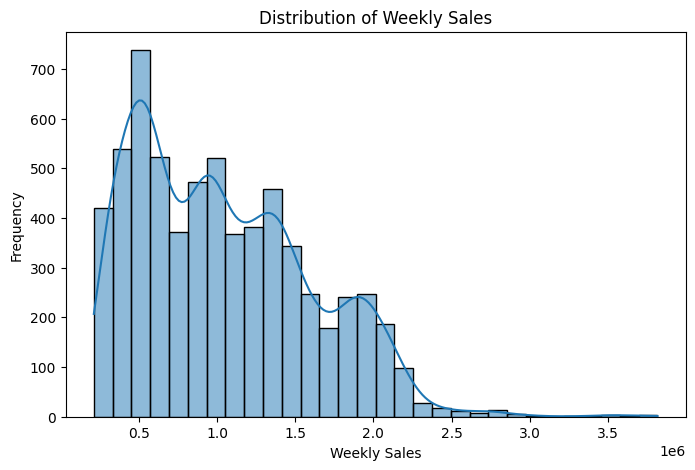

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Weekly_Sales"],
    bins=30,
    kde=True
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

## Observation

- The weekly sales distribution is positively skewed, with most sales values concentrated in the lower and middle ranges.
- A smaller number of weeks recorded significantly higher sales, creating a long right tail in the distribution.
- The variation in weekly sales indicates differences in sales performance across different weeks.
- Most weeks have moderate sales levels, while extreme high-sales periods occur less frequently.
- Further analysis of factors such as holidays, store performance, and time trends can help identify the reasons behind these sales variations.

## Business Question 2: Which stores generate the highest sales?

In [ ]:
store_sales = (
    df.groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales.head(10)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


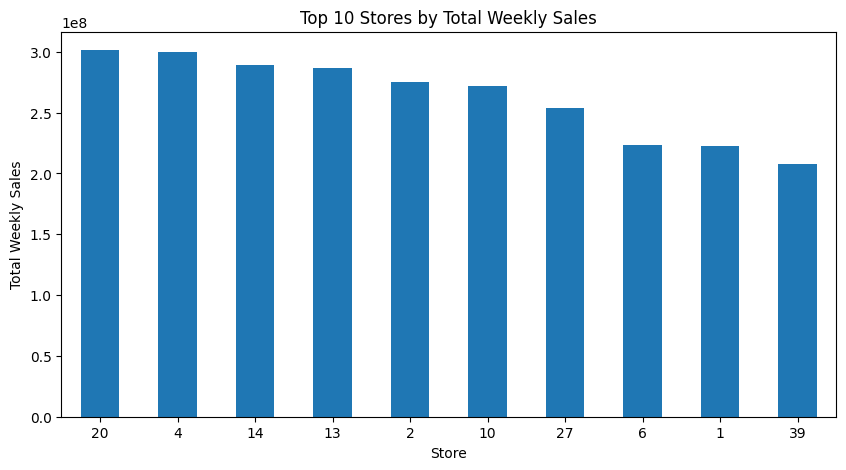

In [ ]:
plt.figure(figsize=(10,5))

store_sales.head(10).plot(kind="bar")

plt.title("Top 10 Stores by Total Weekly Sales")
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")

plt.xticks(rotation=0)
plt.show()

## Observation

- Total weekly sales vary across the top 10 stores, with Store 20 recording the highest sales, followed closely by Stores 4, 14, and 13.
- The difference between the highest- and lowest-performing stores in the top 10 is substantial, indicating variation in overall sales performance.
- Several stores have comparable sales totals, while others lag behind, suggesting opportunities for further investigation

## Business Question 3: How do sales vary over time?

In [ ]:
daily_sales = (
    df.groupby("Date")["Weekly_Sales"]
    .sum()
)

daily_sales.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


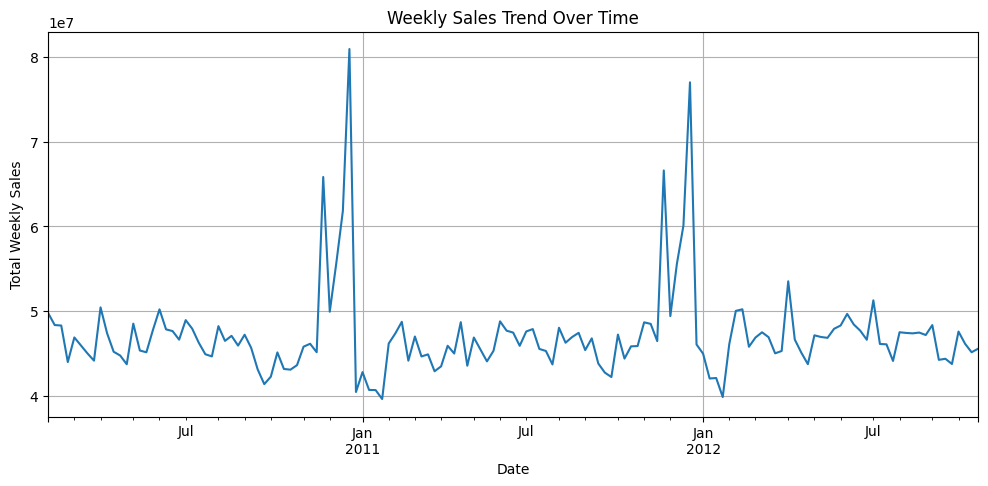

In [ ]:
plt.figure(figsize=(12,5))

daily_sales.plot()

plt.title("Weekly Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.grid()
plt.show()

## Observation

- Weekly sales fluctuate over the analyzed period, showing changes in customer demand over time.
- The trend indicates the presence of seasonal patterns, with certain periods experiencing higher sales compared to others.
- Sales peaks can be observed during specific weeks, which may indicate increased demand during promotional or holiday periods.
- Understanding these sales patterns can help businesses improve inventory planning and prepare for high-demand periods.

## Business Question 4: Do holiday weeks impact sales performance?

In [ ]:
holiday_sales = (
    df.groupby("Holiday_Flag")["Weekly_Sales"]
    .mean()
)

holiday_sales

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


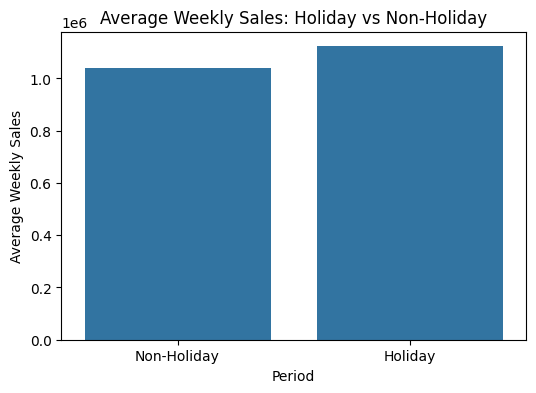

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=holiday_sales.index,
    y=holiday_sales.values
)

plt.xticks(
    [0,1],
    ["Non-Holiday", "Holiday"]
)

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Period")
plt.ylabel("Average Weekly Sales")

plt.show()

## Observation

- Average weekly sales differ between holiday and non-holiday periods.
- Holiday weeks show changes in customer purchasing patterns compared to regular weeks.
- The difference in sales indicates that holidays may have an impact on retail demand.
- Businesses can use holiday sales patterns to improve inventory planning and promotional strategies.

## Business Question 5: Which stores consistently perform better than others?

In [ ]:
store_performance = (
    df.groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

store_performance

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


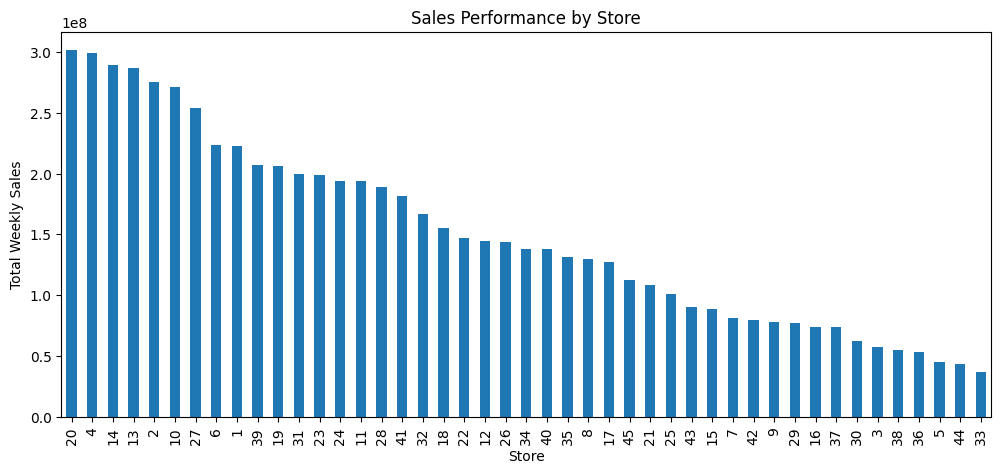

In [ ]:
plt.figure(figsize=(12,5))

store_performance.plot(kind="bar")

plt.title("Sales Performance by Store")
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")

plt.xticks(rotation=90)
plt.show()

In [ ]:
print("Top 5 Performing Stores:")
print(store_performance.head(5))

print("\nLowest Performing Stores:")
print(store_performance.tail(5))

Top 5 Performing Stores:
Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

Lowest Performing Stores:
Store
38    55159626.42
36    53412214.97
5     45475688.90
44    43293087.84
33    37160221.96
Name: Weekly_Sales, dtype: float64


## Observation

- Store performance varies significantly across different locations.
- A few stores contribute a larger share of total sales compared to other stores.
- The highest-performing stores show stronger sales generation over the analyzed period.
- Lower-performing stores may require further investigation to understand factors affecting their sales performance.
- Comparing store performance helps identify successful locations and areas where improvements may be needed.

## Business Question 6: What is the relationship between temperature and weekly sales?

In [ ]:
correlation = df["Temperature"].corr(df["Weekly_Sales"])

print("Correlation between Temperature and Weekly Sales:", correlation)

Correlation between Temperature and Weekly Sales: -0.06381001317946955


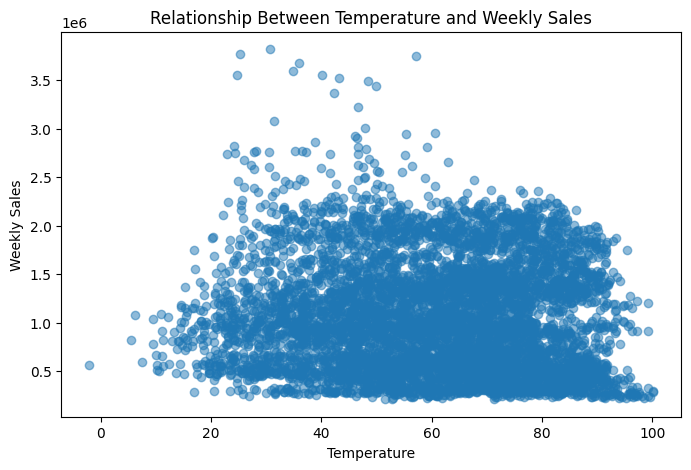

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Temperature"],
    df["Weekly_Sales"],
    alpha=0.5
)

plt.title("Relationship Between Temperature and Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()


## Observation

- The scatter plot shows the relationship between temperature and weekly sales.
- The correlation value indicates whether temperature has a positive or negative impact on sales.
- A correlation close to 0 suggests that temperature has little influence on weekly sales.
- A positive correlation indicates that sales tend to increase with temperature.
- A negative correlation indicates that sales tend to decrease as temperature rises.
- Overall, temperature alone may not be a strong predictor of sales because customer purchasing decisions are also affected by holidays, promotions, fuel prices, and store-specific factors.

## Business Question 7: How do fuel prices affect weekly sales?

In [ ]:
fuel_sales_corr = df["Fuel_Price"].corr(df["Weekly_Sales"])

print("Correlation between Fuel Price and Weekly Sales:", fuel_sales_corr)

Correlation between Fuel Price and Weekly Sales: 0.009463786314475114


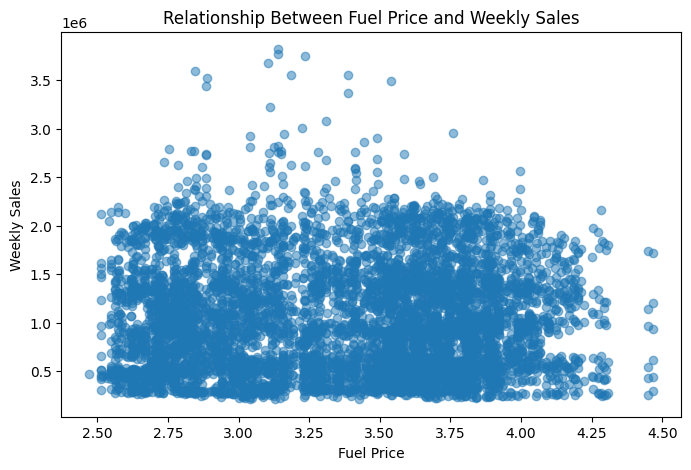

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Fuel_Price"],
    df["Weekly_Sales"],
    alpha=0.5
)

plt.title("Relationship Between Fuel Price and Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.show()


## Observation

- The scatter plot shows the relationship between fuel prices and weekly sales.
- The correlation value indicates whether fuel prices have a positive or negative impact on sales.
- A negative correlation suggests that higher fuel prices may reduce customer spending.
- A weak correlation indicates that fuel prices alone do not strongly influence weekly sales.
- Other factors such as store location, holidays, and economic conditions may have a larger impact on sales.

## Business Question 8: How does unemployment affect weekly sales?

In [ ]:
unemployment_sales_corr = df["Unemployment"].corr(df["Weekly_Sales"])

print("Correlation between Unemployment and Weekly Sales:", unemployment_sales_corr)

Correlation between Unemployment and Weekly Sales: -0.10617608965795429


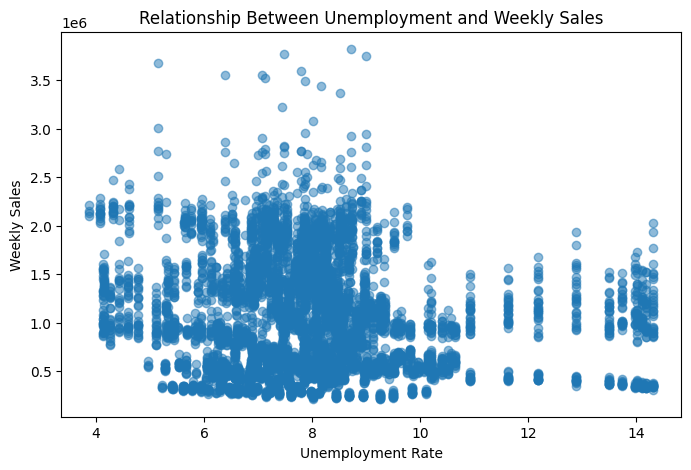

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Unemployment"],
    df["Weekly_Sales"],
    alpha=0.5
)

plt.title("Relationship Between Unemployment and Weekly Sales")
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")

plt.show()


## Observation

- The scatter plot shows the relationship between unemployment rates and weekly sales.
- The correlation value indicates whether unemployment has a positive or negative impact on sales.
- A negative correlation suggests that higher unemployment may reduce customer spending.
- A weak correlation indicates that unemployment alone may not strongly affect weekly sales.
- Sales are also influenced by other factors such as store location, holidays, promotions, and seasonal trends.

## Business Question 9: How does CPI affect weekly sales?

In [ ]:
cpi_sales_corr = df["CPI"].corr(df["Weekly_Sales"])

print("Correlation between CPI and Weekly Sales:", cpi_sales_corr)

Correlation between CPI and Weekly Sales: -0.07263416204017632


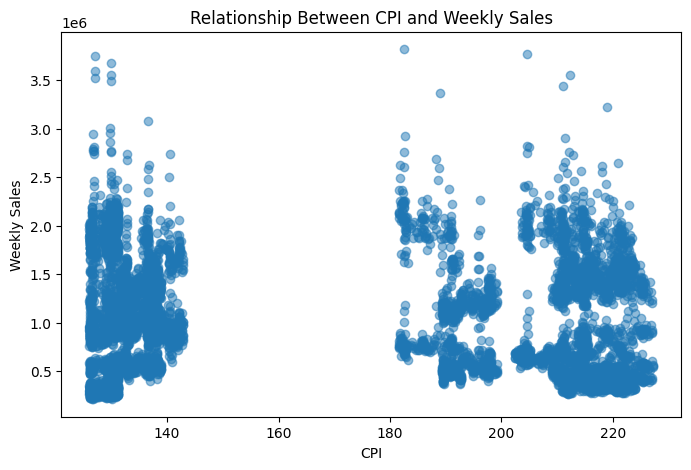

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["CPI"],
    df["Weekly_Sales"],
    alpha=0.5
)

plt.title("Relationship Between CPI and Weekly Sales")
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")

plt.show()


## Observation

- The scatter plot shows the relationship between CPI and weekly sales.
- The correlation value indicates whether CPI has a positive or negative impact on sales.
- A negative correlation may suggest that higher prices reduce customer purchasing power.
- A positive correlation may indicate that sales increase during periods of higher CPI.
- A weak correlation suggests that CPI alone does not strongly determine weekly sales.
- Other factors such as store performance, holidays, and seasonal patterns may have a greater influence on sales.

## Business Question 10: Which economic factors have the strongest relationship with weekly sales?

In [ ]:
economic_factors = [
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Temperature"
]

correlation = (
    df[economic_factors + ["Weekly_Sales"]]
    .corr()["Weekly_Sales"]
    .drop("Weekly_Sales")
    .sort_values(ascending=False)
)

correlation

,Weekly_Sales
Fuel_Price,0.009464
Temperature,-0.063810
CPI,-0.072634
Unemployment,-0.106176


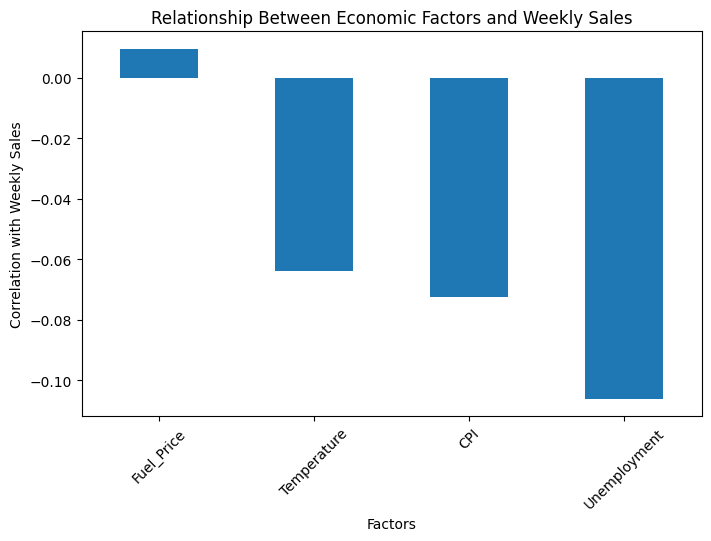

In [ ]:
plt.figure(figsize=(8,5))

correlation.plot(kind="bar")

plt.title("Relationship Between Economic Factors and Weekly Sales")
plt.xlabel("Factors")
plt.ylabel("Correlation with Weekly Sales")

plt.xticks(rotation=45)
plt.show()


## Observation

- Different economic factors show different levels of relationship with weekly sales.
- Factors with higher correlation values have a stronger association with sales changes.
- A positive correlation indicates that sales tend to increase when the factor increases.
- A negative correlation indicates that sales tend to decrease when the factor increases.
- Economic factors alone may not fully explain sales changes because store characteristics, holidays, and seasonal patterns also influence demand.

In [ ]:
# Sales trend
sales_trend = df.groupby("Date")["Weekly_Sales"].sum()

# Store sales
store_sales = (
    df.groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Holiday sales
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

# Economic correlation
corr = (
    df[["Weekly_Sales","Temperature","Fuel_Price","CPI","Unemployment"]]
    .corr()["Weekly_Sales"]
    .drop("Weekly_Sales")
)

Text(0, 0.5, 'Correlation')

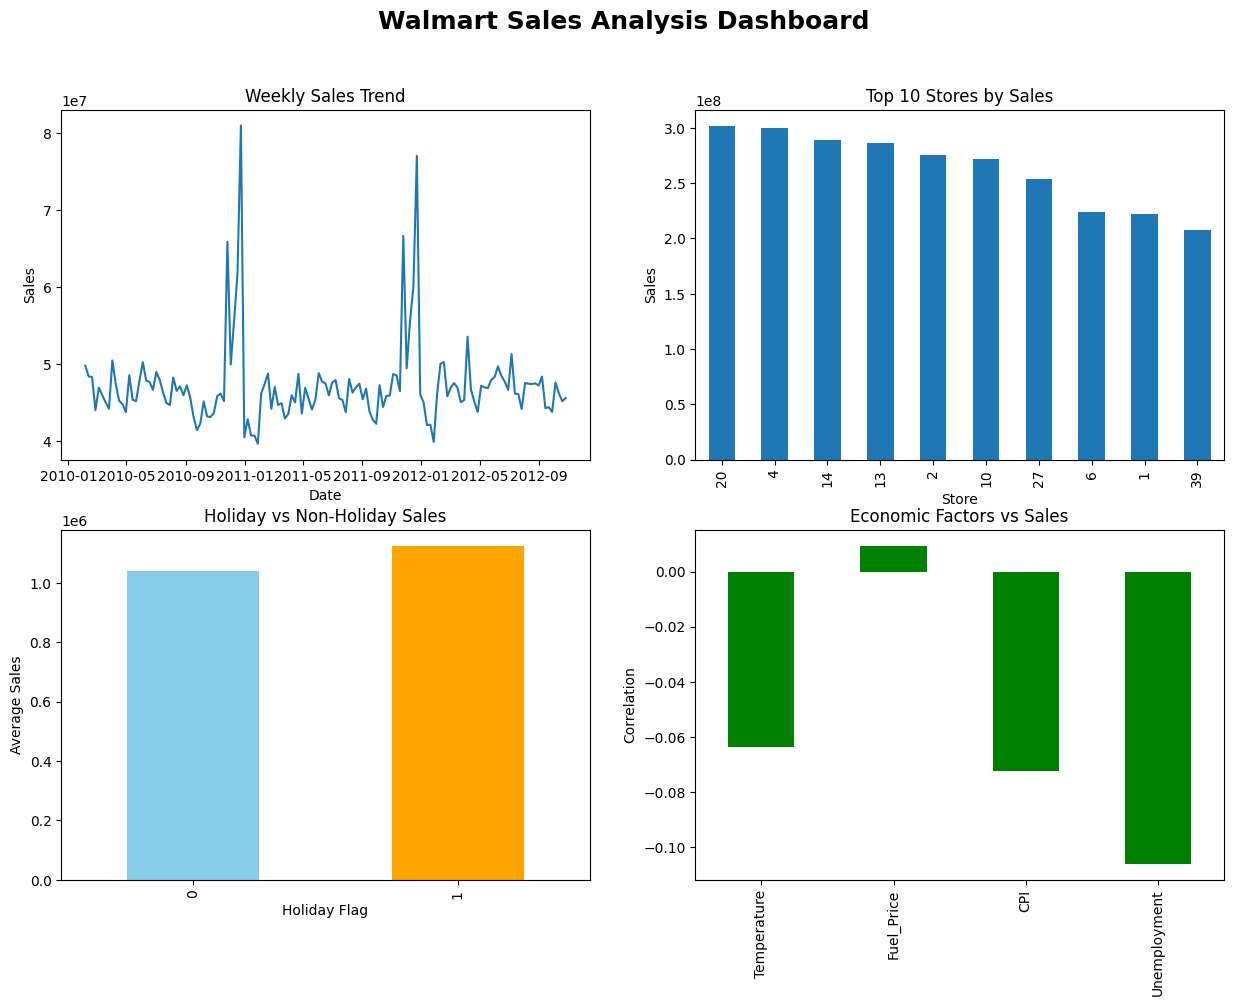

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(15,10)
)

fig.suptitle(
    "Walmart Sales Analysis Dashboard",
    fontsize=18,
    fontweight="bold"
)
axes[0,0].plot(
    sales_trend.index,
    sales_trend.values
)

axes[0,0].set_title("Weekly Sales Trend")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Sales")

store_sales.head(10).plot(
    kind="bar",
    ax=axes[0,1]
)

axes[0,1].set_title("Top 10 Stores by Sales")
axes[0,1].set_xlabel("Store")
axes[0,1].set_ylabel("Sales")

holiday_sales.plot(
    kind="bar",
    ax=axes[1,0],
    color=["skyblue","orange"]
)

axes[1,0].set_title(
    "Holiday vs Non-Holiday Sales"
)

axes[1,0].set_xlabel(
    "Holiday Flag"
)

axes[1,0].set_ylabel(
    "Average Sales"
)

corr.plot(
    kind="bar",
    ax=axes[1,1],
    color="green"
)

axes[1,1].set_title(
    "Economic Factors vs Sales"
)

axes[1,1].set_ylabel(
    "Correlation"
)

# Key Findings

## 1. Sales Trend Analysis
- Weekly sales show fluctuations throughout the given period.
- Certain weeks have significant sales spikes, which may be influenced by seasonal demand, holidays, or promotional activities.
- Understanding these trends helps in predicting future sales patterns.

## 2. Store Performance Analysis
- Sales performance varies across different stores.
- A few stores contribute a larger share of total revenue compared to others.
- High-performing stores can be studied to identify successful strategies that can be applied to other locations.

## 3. Impact of Holidays on Sales
- Holiday weeks generally show higher average sales compared to non-holiday weeks.
- Increased customer demand during holiday periods creates opportunities for better promotions and inventory planning.

## 4. Impact of Economic Factors
- Factors such as temperature, fuel price, CPI, and unemployment have a relatively weak relationship with weekly sales.
- Sales are likely influenced more by store-specific factors, customer behavior, promotions, and seasonal patterns.

## 5. Store Sales Variation
- Some stores have more stable sales patterns, while others experience larger fluctuations.
- Understanding these variations helps in improving sales forecasting and resource planning.




# Business Recommendations

## 1. Improve Inventory Planning
- Use historical sales trends to maintain proper stock levels.
- Increase inventory before high-demand periods such as holidays and seasonal peaks.

## 2. Focus on High-Performing Stores
- Analyze successful stores to understand factors contributing to higher sales.
- Allocate resources, promotions, and inventory based on store performance.

## 3. Develop Better Holiday Strategies
- Plan special offers and promotions during holiday periods.
- Prepare additional stock and staff availability to handle increased customer demand.

## 4. Analyze Low-Performing Stores
- Investigate reasons behind lower sales performance.
- Consider factors such as customer demand, location, and operational strategies for improvement.

## 5. Use Data for Future Forecasting
- Build sales forecasting models using historical sales data.
- Use predictions to support decisions related to inventory, staffing, and marketing.




# Conclusion

The analysis provides insights into Walmart's sales patterns, store performance, holiday effects, and the influence of external factors. The findings can help improve business planning, optimize resources, and support data-driven decision-making.